<a href="https://colab.research.google.com/github/prince-musonda/my-journey-to-artificial-intelligence/blob/main/FashionMNISTModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import torchvision
from torchvision.transforms import ToTensor
from matplotlib import pyplot as plt

# **Load the data**

In [2]:
train_data = torchvision.datasets.FashionMNIST(root='data',download=True,train=True,transform=ToTensor(),target_transform=None)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 276kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


In [3]:
test_data = torchvision.datasets.FashionMNIST(root='data',download=True,train=False,transform=ToTensor(),target_transform=None)

# **let us visualize some sample data**

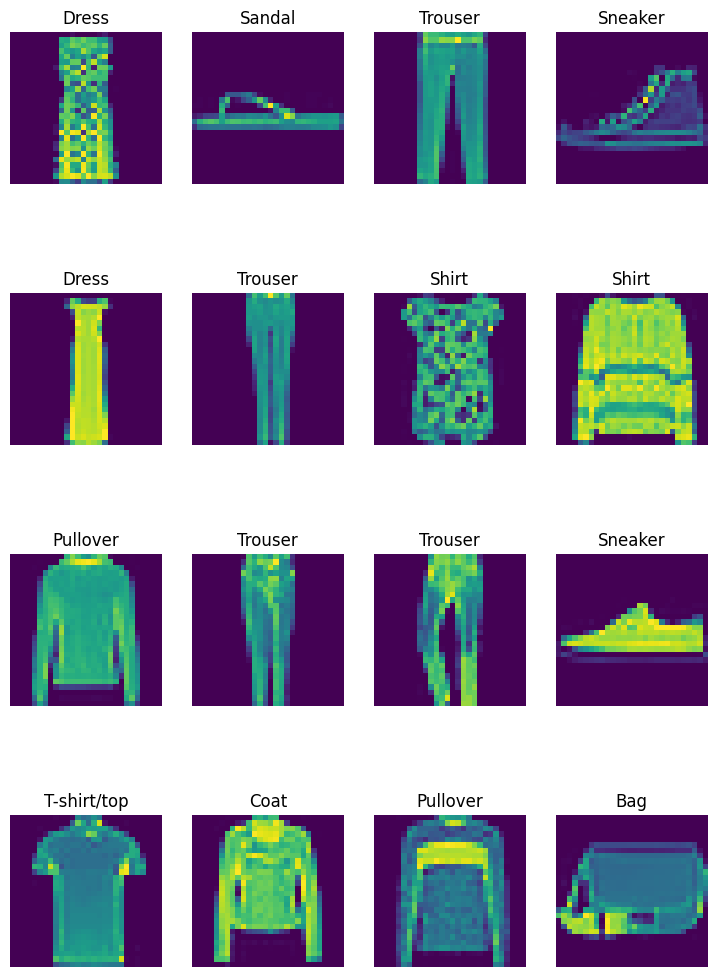

In [4]:
torch.manual_seed(50)
fig = plt.figure(figsize=(9,13))
rows = 4
columns = 4

for i in range(1, rows*columns + 1):
  random_idx = torch.randint(0,len(train_data.data),size=(1,)).item()
  image, lable = train_data[random_idx]
  fig.add_subplot(rows,columns,i)
  image = image.squeeze()
  plt.imshow(image)
  title = train_data.classes[lable]
  plt.title(title)
  plt.axis(False)

# **Prepare DataLoader**

In [5]:
from torch.utils.data import DataLoader

In [6]:
train_dataloader = DataLoader(train_data, shuffle=True, batch_size=32)
test_dataloader = DataLoader(test_data, shuffle=False, batch_size=32)

In [7]:
nn.Flatten()(next(iter(train_dataloader))[0])

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.3294, 0.1137, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

# **Create model**

In [45]:
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape: int , hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        #nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        #nn.ReLU()
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

In [46]:
model_1 = FashionMNISTModel(input_shape=28*28, hidden_units=10, output_shape=len(train_data.classes))

# **Set up optimizer, loss, and evaluation metrics**

In [47]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [48]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

# **create training loop and train model on batches of data**

In [49]:
# this is for showing a progress bar
from tqdm import tqdm

In [50]:
# se the seed
torch.manual_seed(42)
# set number of epochs
epoches = 30
# start training loop
for epoch in tqdm(range(epoches)):
  print(f"epoch {epoch}\n...............")
  # training
  loss = 0
  #loop through the batches
  for batch, (x,y) in enumerate(train_dataloader):
    model_1.train()
    #forward propagation
    prediction = model_1(x)
    # calculate loss
    train_loss = loss_fn(prediction, y)
    loss += train_loss  # loss per epoch
    # optimizer zero grad
    optimizer.zero_grad()
    # back propagation
    train_loss.backward()
    # update parameters
    optimizer.step()

    #print out how many samples have been seen
    if batch % 400 == 0:
      print(f"{batch * len(x)} / {len(train_dataloader.dataset)} samples looked at")
  # average loss per batch
  loss /= len(train_dataloader)

  # evaluation on test data
  model_1.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for x, y  in test_dataloader:
      test_pred = model_1(x)
      # calculate loss
      test_loss += loss_fn(test_pred, y)
      # calculate loss
      test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    # average loss on test data per batch
    test_loss /= len(test_dataloader)
    # average accuracy
    test_acc /= len(test_dataloader)

  # print what is going on
  print(f"\ntrain loss {loss:.5f} ¦¦  test loss {test_loss: .5f}, accu {test_acc:.2f}%")



  0%|          | 0/30 [00:00<?, ?it/s]

epoch 0
...............
0 / 60000 samples looked at
12800 / 60000 samples looked at
25600 / 60000 samples looked at
38400 / 60000 samples looked at
51200 / 60000 samples looked at


  3%|▎         | 1/30 [00:11<05:20, 11.05s/it]


train loss 0.58609 ¦¦  test loss  0.50276, accu 82.42%
epoch 1
...............
0 / 60000 samples looked at
12800 / 60000 samples looked at
25600 / 60000 samples looked at
38400 / 60000 samples looked at
51200 / 60000 samples looked at


  7%|▋         | 2/30 [00:22<05:10, 11.08s/it]

...


train loss 0.39730 ¦¦  test loss  0.44963, accu 84.23%
epoch 28
...............
0 / 60000 samples looked at
12800 / 60000 samples looked at
25600 / 60000 samples looked at
38400 / 60000 samples looked at
51200 / 60000 samples looked at


 97%|█████████▋| 29/30 [05:16<00:10, 10.80s/it]


train loss 0.39624 ¦¦  test loss  0.47780, accu 83.16%
epoch 29
...............
0 / 60000 samples looked at
12800 / 60000 samples looked at
25600 / 60000 samples looked at
38400 / 60000 samples looked at
51200 / 60000 samples looked at


100%|██████████| 30/30 [05:27<00:00, 10.91s/it]


train loss 0.39685 ¦¦  test loss  0.45953, accu 83.82%


In [67]:
def classify(data, model: nn.Module = model_1, classes=train_data.classes):
  model.eval()
  with torch.inference_mode():
    predictions = model(data)
    prediction = torch.softmax(predictions,dim=-1).argmax(dim=-1)
    return classes[prediction]

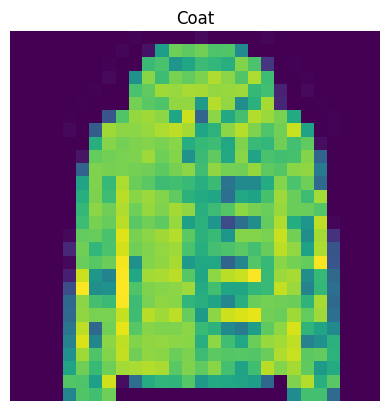

In [79]:
# pick random inage from test set
random_idx = torch.randint(0,len(test_data), size=(1,)).item()
image, label = test_data[random_idx]
plt.imshow(image.reshape((28,28)))
plt.title(test_data.classes[label])
plt.axis(False)
plt.show()

In [80]:
classify(image)

'Coat'